# Exercises

We have four exercises in this section:
1. Introduce normalization of features to kNN example
2. Rewrite the CART method to the Gini index.
3. Use pydot do draw the tree for C4.5 example.

In [1]:
# imports
import numpy as np
import tensorflow_datasets as tfds
import pandas as pd
import math
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
import pydot
import copy
import pickle
from IPython.display import Image

In [2]:
# download data
ds = tfds.load('titanic', split='train', shuffle_files=True)

from google.colab import drive
drive.mount('/content/drive')

with open("/content/drive/MyDrive/Colab-Notebooks/Machine-Learning/Lab-4/c45_tree.pkl", "rb") as f:
    split_history_c45 = pickle.load(f)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/titanic/incomplete.W965KL_4.0.0/titanic-train.tfrecord*...:   0%|         …

Dataset titanic downloaded and prepared to /root/tensorflow_datasets/titanic/4.0.0. Subsequent calls will reuse this data.
Mounted at /content/drive


## Exercise 1: Introduce normalization of features for kNN example

In [3]:
# dataset prep
titanic_df = tfds.as_dataframe(ds)

columns = ['survived','age', 'fare']
features = columns[1:]
titanic_df = titanic_df[columns].replace([np.inf, -np.inf], np.nan).dropna()
titanic_df = titanic_df[titanic_df['fare'] > 30]

titanic_df

,survived,age,fare
3,0,18.0,73.500000
9,1,30.0,93.500000
11,0,21.0,77.287498
12,0,21.0,73.500000
17,1,54.0,59.400002
...,...,...,...
1282,1,1.0,37.004200
1284,1,23.0,63.358299
1292,1,24.0,65.000000
1302,0,16.0,46.900002


In [4]:
# dataset normalization
normalized_titanic_df = titanic_df.copy()

scaler = MinMaxScaler()
normalized_titanic_df[features] = scaler.fit_transform(normalized_titanic_df[features])

normalized_titanic_df

,survived,age,fare
3,0,0.246753,0.090054
9,1,0.402597,0.131525
11,0,0.285714,0.097907
12,0,0.285714,0.090054
17,1,0.714286,0.060816
...,...,...,...
1282,1,0.025974,0.014377
1284,1,0.311688,0.069024
1292,1,0.324675,0.072428
1302,0,0.220779,0.034897


### Check performance:

In [5]:
# prediction evaluation
def predict_and_calculate_accuracy(dataset):
    k = 5

    survivded_df = dataset[dataset['survived']==1].sample(50, random_state=12345)
    not_survivded_df = dataset[dataset['survived']==0].sample(50, random_state=54321)

    train_set = survivded_df.sample(40, random_state=12345)
    train_set = pd.concat([train_set, not_survivded_df.sample(40, random_state=54321)])
    plot_train_set = train_set
    train_set_labels = train_set['survived']
    train_set = train_set[features]

    test_set = survivded_df.sample(10, random_state=12345)
    test_set = pd.concat([test_set, not_survivded_df.sample(10, random_state=54321)])
    plot_test_set = test_set
    test_set_labels = test_set['survived']
    test_set = test_set[features]

    def calculate_distance(x, v):
        return math.sqrt((x[0] - v[0]) ** 2 + (x[1] - v[1]) ** 2)

    def calculate_distance_matrix():
        distance_matrix = np.zeros((len(data_set),len(data_set)))
        for i in range(len(data_set)):
            for j in range(len(data_set)):
                distance_matrix[i, j] = calculate_distance(data_set[i], data_set[j])
        return distance_matrix

    def find_closest_objects(x, k):
        distances = []
        i = 0
        for item in train_set.values:
            distances.append([i, calculate_distance(x, item)])
            i = i + 1
        distances=np.array(distances)
        label_ids = distances[distances[:, 1].argsort()][:k,0]
        return [int(item) for item in label_ids]


    def predict():
        predictions = []
        for item in test_set.values:
            label_ids = find_closest_objects(item, k)
            counts = np.bincount(train_set_labels.values[label_ids])
            label = np.argmax(counts)
            predictions.append(label)
        return predictions

    predictions = predict()
    acc = accuracy_score(test_set_labels, predictions)
    return acc

In [6]:
print(f'Baseline accuracy: {predict_and_calculate_accuracy(titanic_df)}')
print(f'Accuracy after normalization: {predict_and_calculate_accuracy(normalized_titanic_df)}')

Baseline accuracy: 0.6
Accuracy after normalization: 0.75


## Exercise 2: Rewrite the CART method to use Gini index as shown in the lecture

Use Gini index can be calculated with the following equation:
\begin{equation}
I_{G}(X)=1-\sum_{i=1}^{m}p^{2}_{i},
\end{equation}
and
\begin{equation}
I_{G}(\text{feature})=\sum_{i=1}^{n}p_{i}*I_{G}(X_{i}).
\end{equation}

You need to fill the ``calculate_gini`` function and change the ``build`` function a bit.

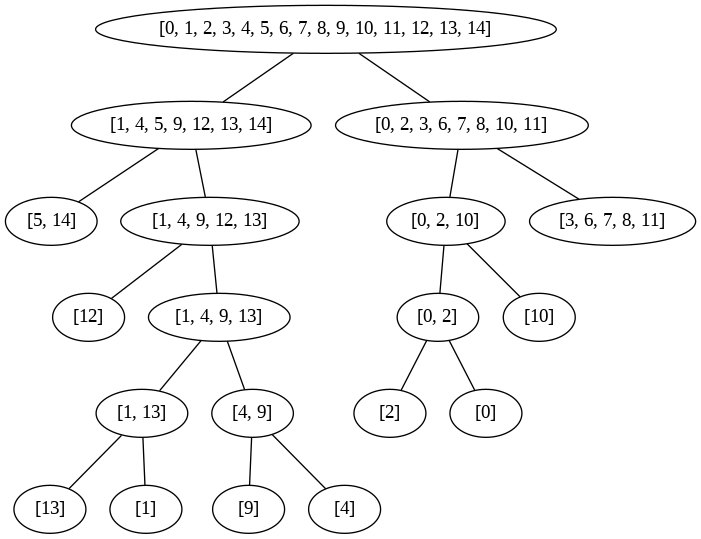

In [7]:
class BinaryLeaf:
    def __init__(self, elements, labels, ids):
        self.L = None
        self.R = None
        self.elements = elements
        self.split_feature = None
        self.labels = labels
        self.completed = False
        self.ids = ids

    def set_R(self, Rleaf):
        self.R = Rleaf

    def set_L(self, Lleaf):
        self.L = Lleaf

    def set_elements(self, elements):
        self.elements = elements

    def get_elements(self):
        return self.elements

    def set_p(self, threshold):
        self.p = threshold

    def get_L(self):
        return self.L

    def get_R(self):
        return self.R

    def set_completed(self):
        self.completed = True

    def is_completed(self):
        return self.completed

    def get_labels(self):
        return self.labels

    def set_split(self, feature):
        self.split_feature = feature

    def get_split(self):
        return self.split_feature

    def set_ids(self, ids):
        self.ids = ids

    def get_ids(self):
        return self.ids

labels = [1, 1, -1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1]
data_set = [[1, 1, 2, 2], [2, 1, 2, 2], [1, 1, 1, 2], [1, 2, 1, 2], [2, 3, 2, 2],
            [2, 2, 1, 2], [3, 2, 2, 1], [1, 3, 2, 2], [3, 3, 2, 1], [2, 3, 1, 2],
            [3, 1, 1, 1], [1, 2, 1, 1], [2, 3, 1, 1], [2, 1, 1, 2], [2, 2, 1, 1]]


labels_count = len(np.unique(labels))

ids = list(range(len(data_set)))
root = BinaryLeaf(data_set, labels, ids)
current_node = root

## helper methods:

def get_unique_labels(labels):
    return np.unique(np.array(labels)).tolist()

def get_unique_values(elements):
    features_number = len(elements[0])
    unique = []
    for i in range(features_number):
        features_list = []
        for j in range(len(elements)):
            features_list.append(elements[j][i])
        unique.append(np.unique(np.array(features_list)))
    return unique

def is_leaf_completed(node):
    if node.is_completed():
        if node.get_L() != None and not node.get_L().is_completed():
            return node.get_L()
        elif node.get_R() != None and not node.get_R().is_completed():
            return node.get_R()
        elif node.get_L() == None and node.get_R() == None:
            return None
        elif node.get_L().is_completed() or node.get_R().is_completed():
            new_node = is_leaf_completed(node.get_L())
            if new_node == None:
                return is_leaf_completed(node.get_R())
            else:
                return new_node
        else:
            return None
    return node

def find_leaf_not_completed(root):
    return is_leaf_completed(root)


## CART methods:

def get_split_candidates(unique_values):
    split_list = []
    for i in range(len(unique_values)):
        current_list = []
        temp_list = copy.deepcopy(unique_values)
        current_list.append(temp_list[i])
        del temp_list[i]
        current_list.append(temp_list)
        split_list.append(current_list)
    return split_list


def get_number_of_labels_for_value(elements, column_id, label):
    count = 0
    if not isinstance(elements, list):
        elements_list = [elements]
    else:
        elements_list = elements

    column_elements = get_node_elements_column(column_id)

    for i in range(len(elements_list)):
        for j in range(len(column_elements)):
            if column_elements[j] == elements_list[i]:
                if current_node.labels[j] == label:
                    count = count + 1
    return count


def get_node_elements_column(column_id):
    return np.array(current_node.elements)[..., column_id].tolist()

def count_number_of_elements(elements, column_id):
    count = 0
    if isinstance(elements, list):
        column_elements = get_node_elements_column(column_id)
        for i in range(len(elements)):
            count = count + column_elements.count(elements[i])
    else:
        count = count + get_node_elements_column(column_id).count(elements)
    return count

# fill:
def calculate_gini(split_candidate, column_id):
    value = split_candidate[0]

    labels_left = []
    labels_right = []

    column_elements = get_node_elements_column(column_id)
    for i in range(len(column_elements)):
        if column_elements[i] == value:
            labels_left.append(current_node.labels[i])
        else:
            labels_right.append(current_node.labels[i])

    n_left = len(labels_left)
    n_right = len(labels_right)
    n_total = n_left + n_right

    # gini helper
    def gini_impurity(labels):
        if not labels: return 0
        counts = [labels.count(lab) for lab in np.unique(labels)]
        impurity = 1.0
        for count in counts:
            p = count / len(labels)
            impurity -= p**2
        return impurity

    gini_left = gini_impurity(labels_left)
    gini_right = gini_impurity(labels_right)

    weighted_gini = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
    return 1 - weighted_gini

def check_completed(labels, elements):
    ratio = len(get_unique_labels(labels))
    if ratio == 1:
        return True
    elements = sorted(elements)
    duplicated = [elements[i] for i in range(len(elements)) if i == 0 or elements[i] != elements[i - 1]]
    if len(duplicated) == 1:
        return True
    return False

def split_node(current_node, value, split_id, split_history):
    left_leaf = []
    left_leaf_labels = []
    left_leaf_ids = []
    right_leaf = []
    right_leaf_labels = []
    right_leaf_ids = []
    for i in range(len(current_node.elements)):
        if current_node.elements[i][split_id] == value:
            left_leaf.append(current_node.elements[i])
            left_leaf_labels.append(current_node.labels[i])
            left_leaf_ids.append(current_node.ids[i])
        else:
            right_leaf.append(current_node.elements[i])
            right_leaf_labels.append(current_node.labels[i])
            right_leaf_ids.append(current_node.ids[i])
    if len(right_leaf_labels) == 0 or len(left_leaf_labels) == 0:
        current_node.set_completed()
        return current_node, split_history
    split_history.append([str(current_node.ids), str(left_leaf_ids)])
    split_history.append([str(current_node.ids), str(right_leaf_ids)])
    current_node.set_L(BinaryLeaf(left_leaf, left_leaf_labels, left_leaf_ids))
    current_node.set_R(BinaryLeaf(right_leaf, right_leaf_labels, right_leaf_ids))
    current_node.set_split(split_id)
    current_node.set_completed()
    if check_completed(left_leaf_labels, left_leaf):
        current_node.L.set_completed()
    if check_completed(right_leaf_labels, right_leaf):
        current_node.R.set_completed()
    return current_node, split_history

def get_current_node():
    return find_leaf_not_completed()

def build(root_node):
    global current_node
    current_node = root_node
    stop_criterion = False
    split_history = []

    while not stop_criterion:
        unique_values = get_unique_values(current_node.get_elements())

        best_gini_gain = -1
        best_feature_id = None
        best_value = None

        for i in range(len(unique_values)):
            if len(unique_values[i]) <= 1:
                continue

            # calculate gini
            split_candidates = get_split_candidates(unique_values[i].tolist())
            for candidate in split_candidates:
                current_gain = calculate_gini(candidate, i)

                if current_gain > best_gini_gain:
                    best_gini_gain = current_gain
                    best_feature_id = i
                    best_value = candidate[0]

        # split
        if best_feature_id is not None:
            current_node, split_history = split_node(current_node, best_value, best_feature_id, split_history)
        else:
            current_node.set_completed()

        new_node = find_leaf_not_completed(root_node)
        if new_node is not None:
            current_node = new_node
        else:
            stop_criterion = True

    return root_node, split_history

def plot_tree(split_history):
    tree = pydot.Dot(graph_type='graph')
    for split in split_history:
        parent_id = split[0]
        child_id = split[1]

        new_edge = pydot.Edge(parent_id, child_id)
        tree.add_edge(new_edge)
    tree.write('cart_tree.png', format='png')

cart_tree, split_history = build(current_node)
plot_tree(split_history)

Image(filename='cart_tree.png')

## Exercise 3: Use pydot do draw the tree for C4.5 example

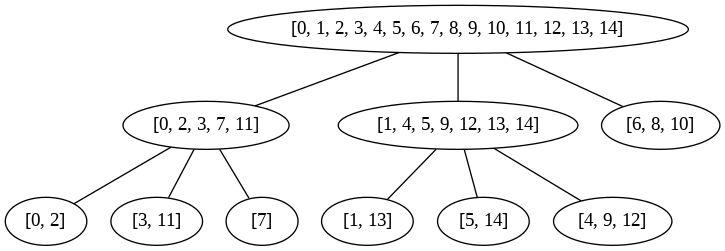

In [8]:
def plot_tree(split_history):
    tree = pydot.Dot(graph_type='graph')
    for split in split_history:
        parent_id = split[0]
        child_id = split[1]

        new_edge = pydot.Edge(parent_id, child_id)
        tree.add_edge(new_edge)
    tree.write('c45_tree.png', format='png')

plot_tree(split_history_c45)

Image(filename='c45_tree.png')